In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/ChestXRay'

Mounted at /content/drive


In [3]:
!pip install torchvision matplotlib seaborn scikit-learn

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, datasets, models
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("All imports done!")

All imports done!


In [5]:
data_dir = '/content/drive/MyDrive/ChestXRay'

for split in ['train', 'val', 'test']:
    for label in ['NORMAL', 'PNEUMONIA']:
        path = os.path.join(data_dir, split, label)
        count = len(os.listdir(path))
        print(f"{split}/{label}: {count} images")

train/NORMAL: 1341 images
train/PNEUMONIA: 3875 images
val/NORMAL: 8 images
val/PNEUMONIA: 8 images
test/NORMAL: 234 images
test/PNEUMONIA: 390 images


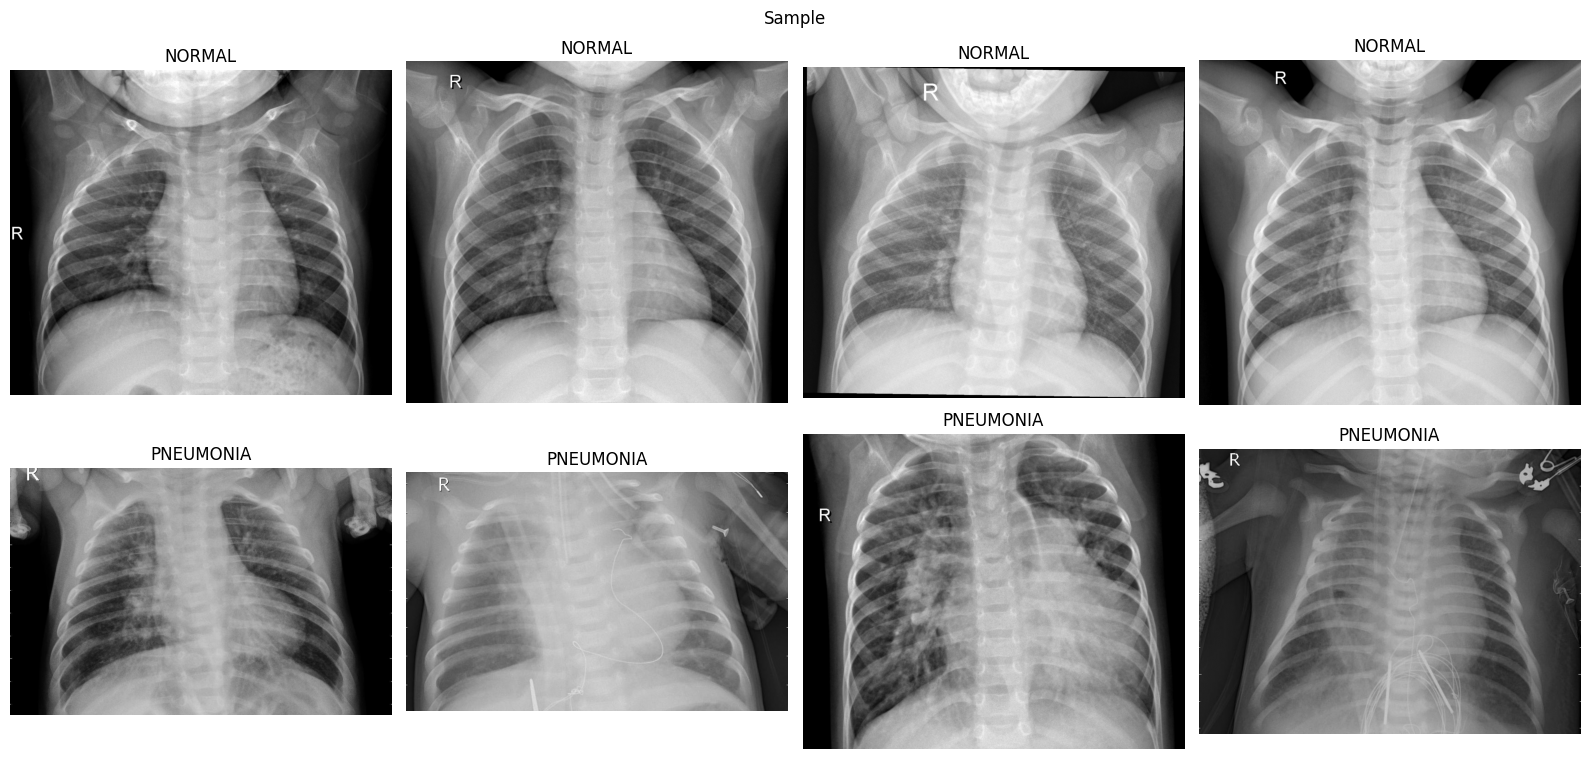

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for row, label in enumerate(['NORMAL', 'PNEUMONIA']):
    folder = os.path.join(data_dir, 'train', label)
    images = os.listdir(folder)[:4]
    for col, img_name in enumerate(images):
        img = Image.open(os.path.join(folder, img_name)).convert('L')
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].set_title(label)
        axes[row][col].axis('off')

plt.suptitle("Sample")
plt.tight_layout()
plt.show()

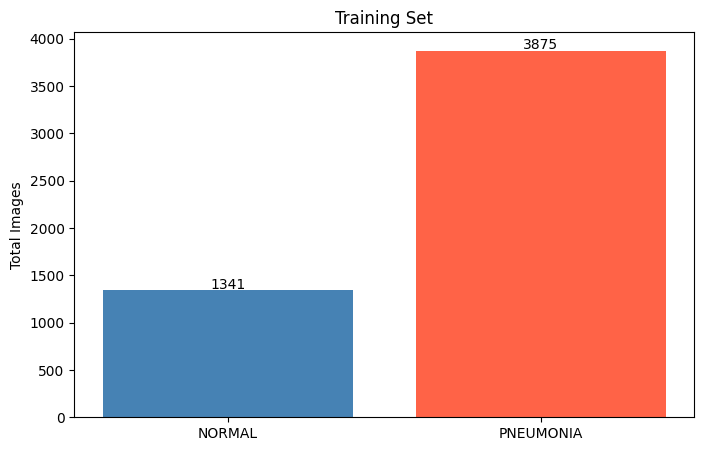

In [7]:
labels = ['NORMAL', 'PNEUMONIA']
train_counts = [
    len(os.listdir(os.path.join(data_dir, 'train', 'NORMAL'))),
    len(os.listdir(os.path.join(data_dir, 'train', 'PNEUMONIA')))
]

plt.figure(figsize=(8, 5))
plt.bar(labels, train_counts, color=['steelblue', 'tomato'])
plt.title('Training Set')
plt.ylabel('Total Images')
for i, v in enumerate(train_counts):
    plt.text(i, v + 20, str(v), ha='center')
plt.show()


In [8]:
from torchvision import datasets
from torch.utils.data import ConcatDataset, random_split


raw_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])


train_raw = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=raw_transform)
val_raw   = datasets.ImageFolder(os.path.join(data_dir, 'val'),   transform=raw_transform)

combined = ConcatDataset([train_raw, val_raw])
total = len(combined)
print(f"Total images for train+val: {total}")




Total images for train+val: 5232


In [9]:
train_size = int(0.85 * total)
val_size   = total - train_size

train_dataset, val_dataset = random_split(
    combined,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {train_size}, Val: {val_size}")

Train: 4447, Val: 785


In [10]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [11]:
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [12]:
train_data = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transform)
val_raw2   = datasets.ImageFolder(os.path.join(data_dir, 'val'),   transform=eval_transform)

combined_eval = ConcatDataset([train_data, val_raw2])

train_size = int(0.85 * len(combined_eval))
val_size   = len(combined_eval) - train_size

train_dataset, val_dataset = random_split(
    combined_eval,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)


In [35]:
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

class_names = train_data.classes
print(f"Classes: {class_names}")

Train batches: 139
Val batches:   25
Test batches:  20
Classes: ['NORMAL', 'PNEUMONIA']


In [14]:
print(f"Actual train size:      {len(train_dataset)}")
print(f"Actual val size:        {len(val_dataset)}")
print(f"Actual test size:       {len(test_dataset)}")

Actual train size:      4447
Actual val size:        785
Actual test size:       624


In [15]:
class_weights = torch.tensor([3.0, 1.0], dtype=torch.float)
print(f"Class weights: NORMAL={class_weights[0]:.2f}, PNEUMONIA={class_weights[1]:.2f}")

Class weights: NORMAL=3.00, PNEUMONIA=1.00


In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")



Using device: cuda


In [17]:
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Sequential(
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, 2)
)
model = model.to(device)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


Trainable parameters: 65,922


In [18]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

In [19]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

In [20]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

In [21]:
EPOCHS = 10
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch [{epoch+1:2d}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/ChestXRay/best_model.pt')

print("Done")

Epoch [ 1/10] Train Loss: 0.3061, Train Acc: 86.71% | Val Loss: 0.2069, Val Acc: 92.48%
Epoch [ 2/10] Train Loss: 0.2052, Train Acc: 91.52% | Val Loss: 0.1908, Val Acc: 90.06%
Epoch [ 3/10] Train Loss: 0.2018, Train Acc: 91.90% | Val Loss: 0.1645, Val Acc: 92.87%
Epoch [ 4/10] Train Loss: 0.1898, Train Acc: 92.49% | Val Loss: 0.1795, Val Acc: 91.85%
Epoch [ 5/10] Train Loss: 0.1823, Train Acc: 92.78% | Val Loss: 0.1531, Val Acc: 93.38%
Epoch [ 6/10] Train Loss: 0.1713, Train Acc: 92.87% | Val Loss: 0.1568, Val Acc: 92.99%
Epoch [ 7/10] Train Loss: 0.1673, Train Acc: 93.19% | Val Loss: 0.1637, Val Acc: 93.12%
Epoch [ 8/10] Train Loss: 0.1677, Train Acc: 93.43% | Val Loss: 0.1502, Val Acc: 93.25%
Epoch [ 9/10] Train Loss: 0.1727, Train Acc: 93.10% | Val Loss: 0.1472, Val Acc: 93.12%
Epoch [10/10] Train Loss: 0.1650, Train Acc: 93.77% | Val Loss: 0.1415, Val Acc: 95.03%
Done


In [22]:
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

EPOCHS_FT = 10

for epoch in range(EPOCHS_FT):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch [{epoch+1:2d}/{EPOCHS_FT}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/ChestXRay/best_model.pt')

print("Done")

Epoch [ 1/10] Train Loss: 0.1198, Train Acc: 95.21% | Val Loss: 0.1237, Val Acc: 94.39%
Epoch [ 2/10] Train Loss: 0.0886, Train Acc: 96.09% | Val Loss: 0.0912, Val Acc: 96.18%
Epoch [ 3/10] Train Loss: 0.0644, Train Acc: 97.53% | Val Loss: 0.0952, Val Acc: 96.82%
Epoch [ 4/10] Train Loss: 0.0618, Train Acc: 97.59% | Val Loss: 0.0825, Val Acc: 97.32%
Epoch [ 5/10] Train Loss: 0.0561, Train Acc: 98.00% | Val Loss: 0.0911, Val Acc: 96.94%
Epoch [ 6/10] Train Loss: 0.0463, Train Acc: 98.16% | Val Loss: 0.0806, Val Acc: 96.82%
Epoch [ 7/10] Train Loss: 0.0495, Train Acc: 98.16% | Val Loss: 0.0756, Val Acc: 96.82%
Epoch [ 8/10] Train Loss: 0.0354, Train Acc: 98.56% | Val Loss: 0.0801, Val Acc: 97.20%
Epoch [ 9/10] Train Loss: 0.0357, Train Acc: 98.52% | Val Loss: 0.0800, Val Acc: 97.58%
Epoch [10/10] Train Loss: 0.0326, Train Acc: 98.72% | Val Loss: 0.0816, Val Acc: 97.07%
Done


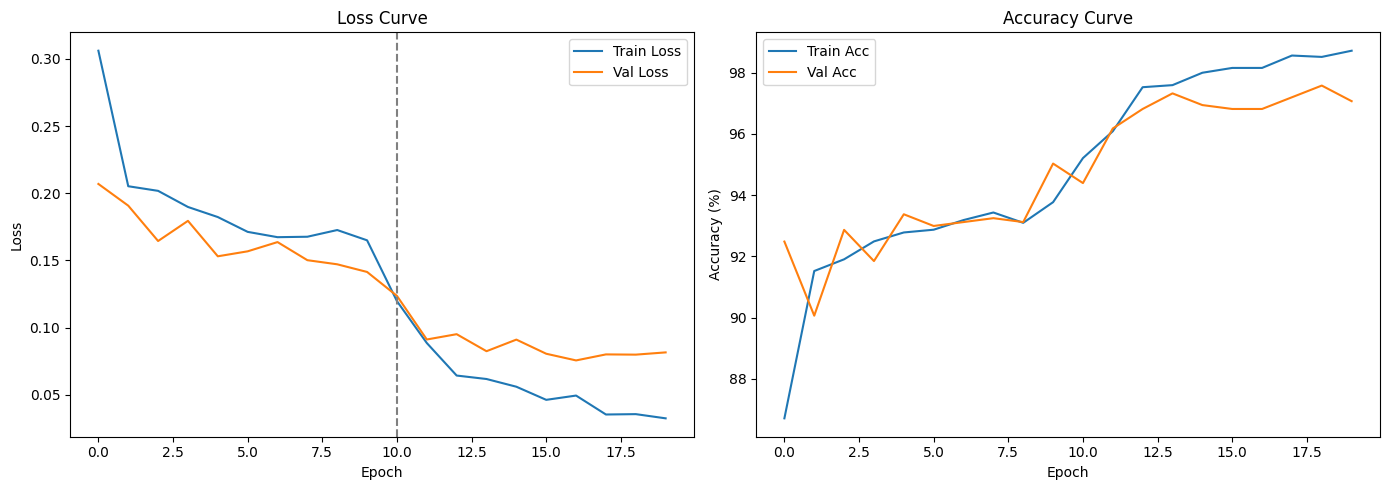

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'],   label='Val Loss')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.axvline(x=10, color='gray', linestyle='--', label='Phase 2 starts')

ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['val_acc'],   label='Val Acc')
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ChestXRay/training_curves.png')
plt.show()


In [34]:
model.load_state_dict(torch.load('/content/drive/MyDrive/ChestXRay/best_model.pt'))
model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())


print("VALIDATION SET RESULTS")

print(classification_report(all_labels, all_preds, target_names=class_names))

roc_auc = roc_auc_score(all_labels, all_probs)
print(f"ROC-AUC Score: {roc_auc:.4f}")

VALIDATION SET RESULTS
              precision    recall  f1-score   support

      NORMAL       0.90      0.98      0.94       213
   PNEUMONIA       0.99      0.96      0.98       572

    accuracy                           0.97       785
   macro avg       0.95      0.97      0.96       785
weighted avg       0.97      0.97      0.97       785

ROC-AUC Score: 0.9973


In [33]:

threshold = 0.65

all_preds_thresh = [1 if p >= threshold else 0 for p in all_probs]


print(f"RESULTS WITH THRESHOLD = {threshold}")

print(classification_report(all_labels, all_preds_thresh, target_names=class_names))

RESULTS WITH THRESHOLD = 0.65
              precision    recall  f1-score   support

      NORMAL       0.96      0.73      0.83       234
   PNEUMONIA       0.86      0.98      0.91       390

    accuracy                           0.89       624
   macro avg       0.91      0.86      0.87       624
weighted avg       0.89      0.89      0.88       624



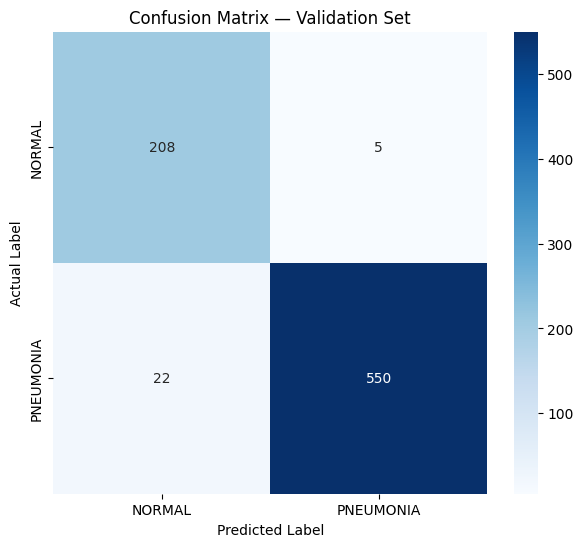

In [26]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Validation Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig('/content/drive/MyDrive/ChestXRay/confusion_matrix_val.png')
plt.show()

In [32]:
model.load_state_dict(torch.load('/content/drive/MyDrive/ChestXRay/best_model.pt'))
model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

threshold = 0.65
all_preds_thresh = [1 if p >= threshold else 0 for p in all_probs]

print(f"TEST SET RESULTS WITH THRESHOLD = {threshold}")
print(classification_report(all_labels, all_preds_thresh, target_names=class_names))

TEST SET RESULTS WITH THRESHOLD = 0.65
              precision    recall  f1-score   support

      NORMAL       0.96      0.73      0.83       234
   PNEUMONIA       0.86      0.98      0.91       390

    accuracy                           0.89       624
   macro avg       0.91      0.86      0.87       624
weighted avg       0.89      0.89      0.88       624



In [28]:
for threshold in [0.70, 0.75, 0.80]:
    all_preds_thresh = [1 if p >= threshold else 0 for p in all_probs]

    from sklearn.metrics import accuracy_score, f1_score
    acc = accuracy_score(all_labels, all_preds_thresh)
    normal_recall = sum(1 for p, l in zip(all_preds_thresh, all_labels) if p == 0 and l == 0) / all_labels.count(0)
    pneumonia_recall = sum(1 for p, l in zip(all_preds_thresh, all_labels) if p == 1 and l == 1) / all_labels.count(1)
    macro_f1 = f1_score(all_labels, all_preds_thresh, average='macro')

    print(f"Threshold {threshold:.2f} → Accuracy: {acc:.2%} | Normal Recall: {normal_recall:.2%} | Pneumonia Recall: {pneumonia_recall:.2%} | Macro F1: {macro_f1:.2%}")

Threshold 0.70 → Accuracy: 88.94% | Normal Recall: 75.21% | Pneumonia Recall: 97.18% | Macro F1: 87.63%
Threshold 0.75 → Accuracy: 90.38% | Normal Recall: 79.06% | Pneumonia Recall: 97.18% | Macro F1: 89.36%
Threshold 0.80 → Accuracy: 90.71% | Normal Recall: 80.34% | Pneumonia Recall: 96.92% | Macro F1: 89.76%


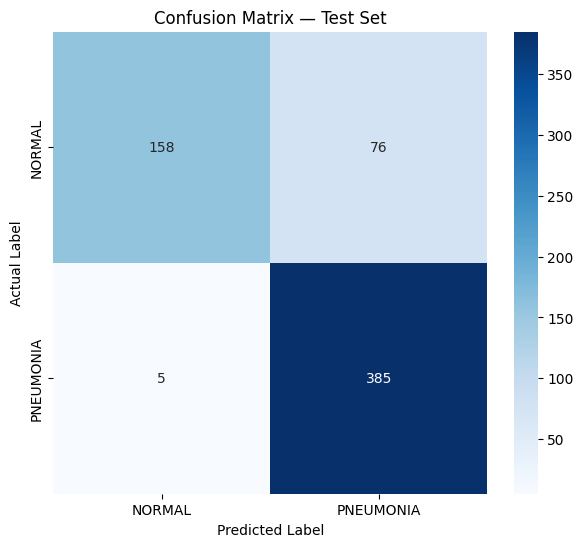

In [29]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig('/content/drive/MyDrive/ChestXRay/confusion_matrix.png')
plt.show()

In [30]:
roc_auc = roc_auc_score(all_labels, all_probs)
print(f"ROC-AUC Score: {roc_auc:.4f}")


ROC-AUC Score: 0.9634


Total wrong predictions: 81 out of 624


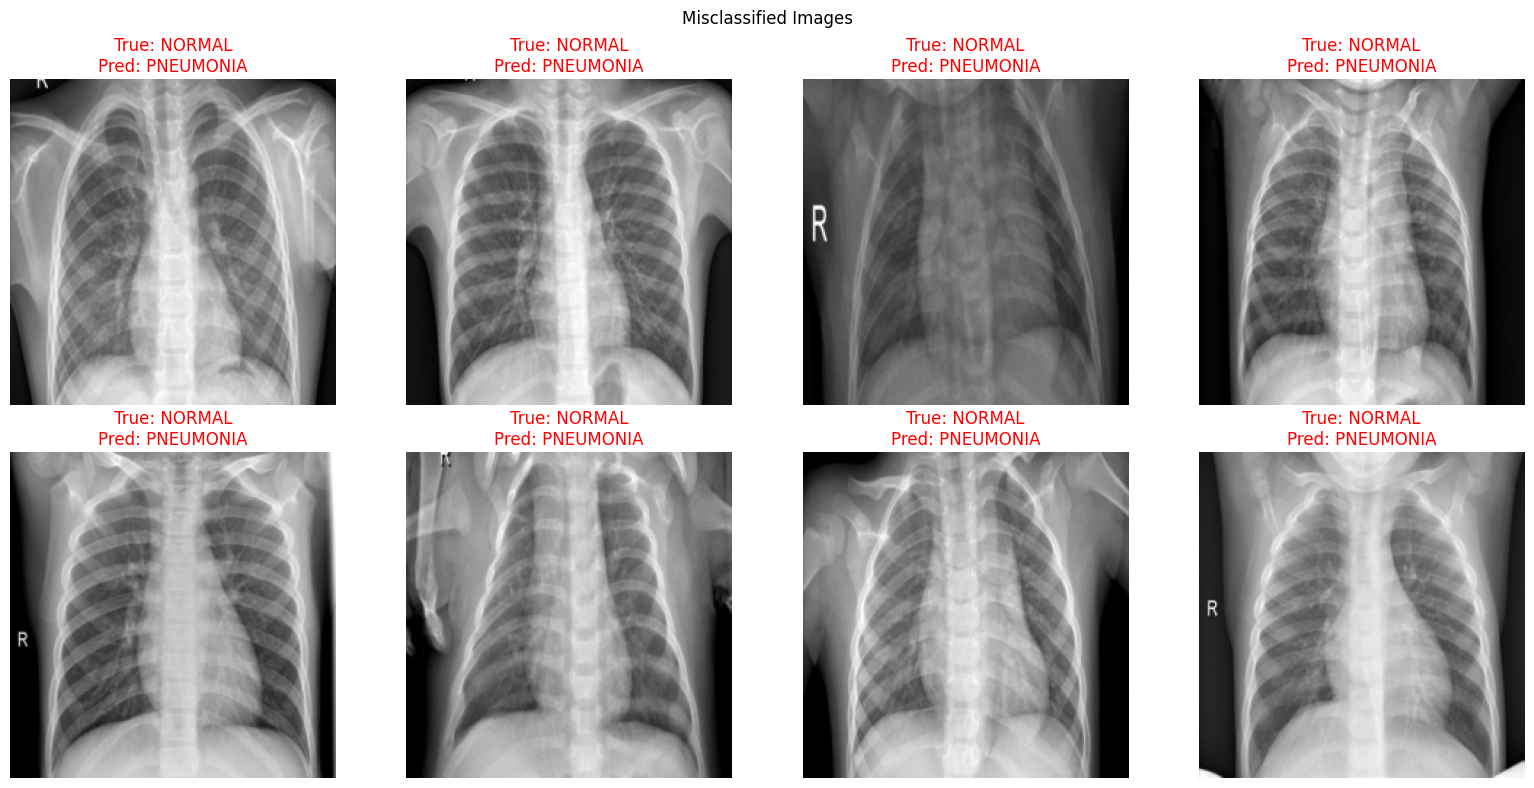

In [31]:
test_dataset_raw = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=eval_transform)
wrong_indices = [i for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p != l]

print(f"Total wrong predictions: {len(wrong_indices)} out of {len(all_labels)}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, idx in zip(axes.flat, wrong_indices[:8]):
    img_tensor, true_label = test_dataset_raw[idx]
    img = img_tensor.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())

    ax.imshow(img[:, :, 0], cmap='gray')
    ax.set_title(f"True: {class_names[true_label]}\nPred: {class_names[all_preds[idx]]}", color='red')
    ax.axis('off')

plt.suptitle("Misclassified Images")
plt.tight_layout()
plt.show()